In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.font_manager as fm

# 경사하강법
$$
w_i \leftarrow w_i-\eta \frac{\partial L}{\partial w_i}
$$

### 수치미분
$$
\begin{equation*}
\frac{df(x)}{dx} = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}
\end{equation*}
$$
<br>
<br>
미분을 하기 위해서는 함수와 위치가 필요하다.

함수 f(x)에서의 x=a 에서의 미분계수

편미분

In [239]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_diff(x):
    return sigmoid(x) * (1 - sigmoid(x))
def sigmoid_tangent(x):
    return sigmoid_diff(x), sigmoid(x) - sigmoid_diff(x) * x

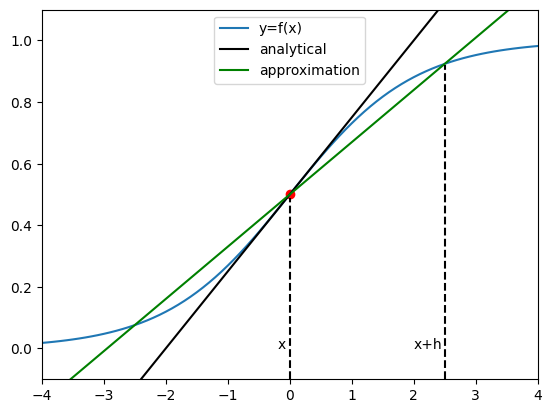

In [240]:
x = np.arange(-6.0, 6.0, 0.1)
y1 = sigmoid(x)
a2, b2 = sigmoid_tangent(0)
y2 = a2 * x + b2
a3 = (sigmoid(2.5) - sigmoid(0)) / 2.5
y3 = a3 * x + b2
plt.plot(x, y1, label='y=f(x)')
plt.plot(x, y2, color='black', label='analytical')
plt.plot(x, y3, color='green', label='approximation')
xv = np.arange(-0.1, 0.5, 0.01)
plt.text(-0.2,0,"x")
plt.plot(np.zeros_like(xv), xv, 'k--')
xhv = np.arange(-0.1, sigmoid(2.5), 0.01)
plt.text(2,0,"x+h")
plt.plot(np.ones_like(xhv)*2.5, xhv, 'k--')
plt.scatter([0],[b2],color='red')
plt.ylim(-0.1,1.1)
plt.xlim(-4,4)
plt.legend(loc='upper center')
plt.show()

In [241]:
h = 1e-4 # 사람들이 여러가지 실험해보니 이게 제일 적당

In [242]:
h

0.0001

In [243]:
np.float32(1e-50) # 이건 너무 작아서 계산이 안됨

np.float32(0.0)

In [244]:
# 수치미분
# f: 방정식, x: 위치
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h)-f(x-h))/(2*h)

$$y = 0.01x^2 + 0.1x$$

수치미분 값

해석적 미분 값

In [245]:
def function_1(x):
    return 0.01*x**2 + 0.1*x

x = 5 에서 미분

In [246]:
numerical_diff(function_1, 5) # 해석적 미분은 0.2 나옴 거의 비슷

0.1999999999990898

x = 10 에서 미분

In [247]:
numerical_diff(function_1, 10) # 해석적 미분은 0.3 나옴 거의 비슷

0.2999999999986347

변수가 2개 이상인 식에 대해 미분 --> 편미분

$$
\begin{equation*}
f(x_{0}, x_{1}) = x_{0}^{2} + x_{1}^{2}
\end{equation*}
$$
<br>
$$
\begin{equation*}
\frac{\partial f}{\partial x_{0}}, \frac{\partial f}{\partial x_{1}}
\end{equation*}
$$

In [248]:
def function_2(x):
    return x[0]**2 + x[1]**2

x0 = 3, x1 = 4 일때 x0의 편미분 구하기

In [249]:
def function_temp1(x0):
    return x0*x0 + 4.0**2

In [250]:
numerical_diff(function_temp1, 3.0)

6.00000000000378

해석적 편미분값

$$2 x_0, \ \ 2 x_1$$

In [251]:
def function_temp2(x1):
    return 3.0**2 + x1*x1
numerical_diff(function_temp2, 4.0)

7.999999999999119

In [252]:
def _numerical_gradient_no_batch(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성
    for idx in range(x.size): #idx 0, 1
        tmp_val = x[idx]
        # f(x+h) 계산
        x[idx] = float(tmp_val) + h # (3,4)의 경우 (3+h, 4)
        fxh1 = f(x)
        # f(x-h) 계산
        x[idx] = tmp_val - h  #(3-h, 4)
        fxh2 = f(x)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원
    return grad

In [253]:
x = np.array([3.0, 4.0])

In [254]:
_numerical_gradient_no_batch(function_2, x)

array([6., 8.])

In [255]:
_numerical_gradient_no_batch(function_2, np.array([0.0, 2.0]))

array([0., 4.])

(3, 4) --> (6, 8)

(0, 2) --> (0, 4)

$$
w_i \leftarrow w_i-\eta \frac{\partial L}{\partial w_i}
$$


$y=x^2$

[2, 4] = w1

미분값
2x = 2

In [256]:
x = 2.0
y = x**2
eta = 0.04 # eta: 최소점을 찾아가는 속도 => 계산속도랑 다름
grad_coeff = 2
x_histhory = [2]
for i in range(100):
    x = x-eta*grad_coeff*x
    x_histhory.append(x)

In [257]:
x_histhory

[2,
 1.84,
 1.6928,
 1.557376,
 1.4327859200000002,
 1.3181630464,
 1.212710002688,
 1.11569320247296,
 1.0264377462751233,
 0.9443227265731134,
 0.8687769084472644,
 0.7992747557714832,
 0.7353327753097646,
 0.6765061532849834,
 0.6223856610221847,
 0.57259480814041,
 0.5267872234891772,
 0.484644245610043,
 0.44587270596123957,
 0.4102028894843404,
 0.3773866583255932,
 0.34719572565954576,
 0.3194200676067821,
 0.29386646219823953,
 0.27035714522238036,
 0.24872857360458994,
 0.22883028771622274,
 0.21052386469892492,
 0.19368195552301093,
 0.17818739908117007,
 0.16393240715467647,
 0.15081781458230234,
 0.13875238941571816,
 0.12765219826246071,
 0.11744002240146385,
 0.10804482060934674,
 0.099401234960599,
 0.09144913616375107,
 0.08413320527065099,
 0.07740254884899891,
 0.071210344941079,
 0.06551351734579268,
 0.06027243595812926,
 0.05545064108147892,
 0.05101458979496061,
 0.04693342261136376,
 0.04317874880245466,
 0.03972444889825829,
 0.03654649298639763,
 0.033622773547

방향미분 $D_\vec{v}f(x)$ 를 해보자. 즉 주어진 x에서 $ \vec{v}$ 방향으로 움직일때 가 얼마나 변하는지 알아보자

$$
D_\vec{v}f(x) = \vec{\nabla}f(x) \cdot \vec{v}
$$

그래디언트

위치에너지

In [258]:
!pip install koreanize-matplotlib

# 계절성 분해를 위한 푸리에 급수

삼각함수들의 합으로 주기함수를 나타내는 방법


$$
y(t) = a_0 + \sum_{n=1}^{\infty} (a_n\cos nwt + b_n\sin nwt)
$$

In [259]:
np.pi

3.141592653589793

In [260]:
x = np.linspace(-4*np.pi, 4*np.pi, 1000)
y = np.sin(x)

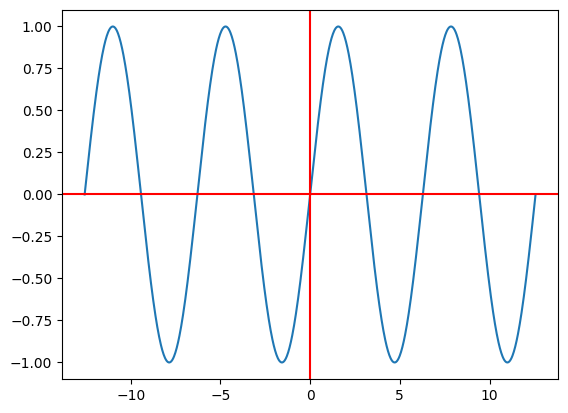

In [261]:
plt.plot(x, y)
plt.axhline(0, -4*np.pi, 4*np.pi, color='red')
plt.axvline(0, -1, 1, color='red')

In [262]:
from scipy import integrate

In [263]:
integrate.quad(np.sin, 0, 2*np.pi)

(2.221501482512777e-16, 4.3998892617845996e-14)

In [264]:
def f2(x):
    return np.sin(2*x)

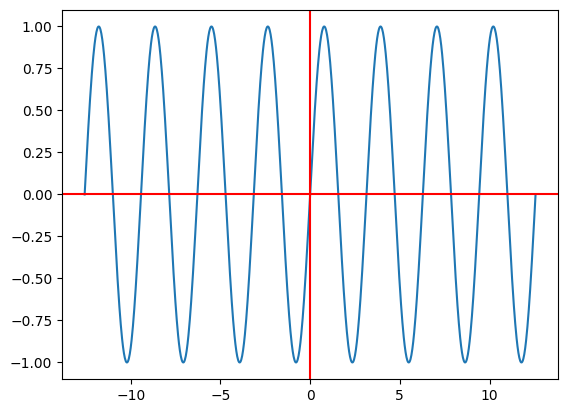

In [265]:
plt.plot(x, f2(x))
plt.axhline(0, -4*np.pi, 4*np.pi, color='red')
plt.axvline(0, -1, 1, color='red')

In [266]:
integrate.quad(f2, 0, 2*np.pi)

(-1.5433597671448142e-16, 4.4205541621600365e-14)

In [267]:
def f3(x):
    return np.sin(x)*np.sin(3*x)

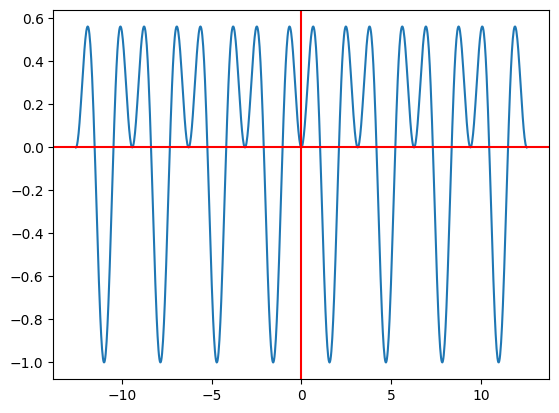

In [268]:
plt.plot(x, f3(x))
plt.axhline(0, -4*np.pi, 4*np.pi, color='red')
plt.axvline(0, -1, 1, color='red')

In [269]:
integrate.quad(f3, 0, 2*np.pi)

(6.975736996017264e-16, 2.033851087546168e-09)

In [270]:
def f4(x):
    return np.sin(3*x)*np.sin(3*x)

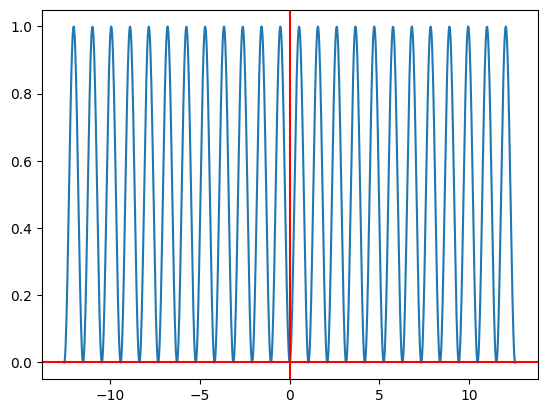

In [271]:
plt.plot(x, f4(x))
plt.axhline(0, -4*np.pi, 4*np.pi, color='red')
plt.axvline(0, -1, 1, color='red')

In [272]:
integrate.quad(f4, 0, 2*np.pi)

(3.141592653589793, 3.4679426214392906e-14)

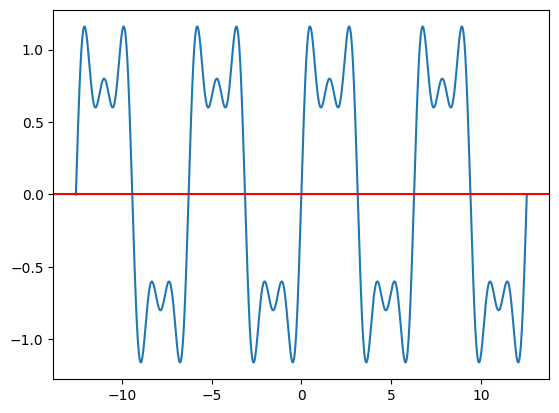

In [273]:
y7 = np.sin(x) + 0.5*np.sin(3*x) + 0.3*np.sin(5*x)
plt.plot(x, y7)
plt.axhline(0, -4*np.pi, 4*np.pi, color='red')

In [274]:
y7 = 2*np.sin(x) + 0.7*np.sin(3*x) + 0.4*np.sin(5*x) + 0.2*np.sin(7*x) + 0.1*np.sin(9*x)

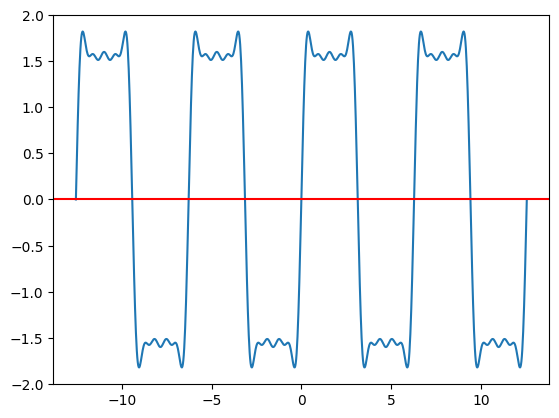

In [275]:
plt.plot(x, y7)
plt.axhline(0, -4*np.pi, 4*np.pi, color='red')

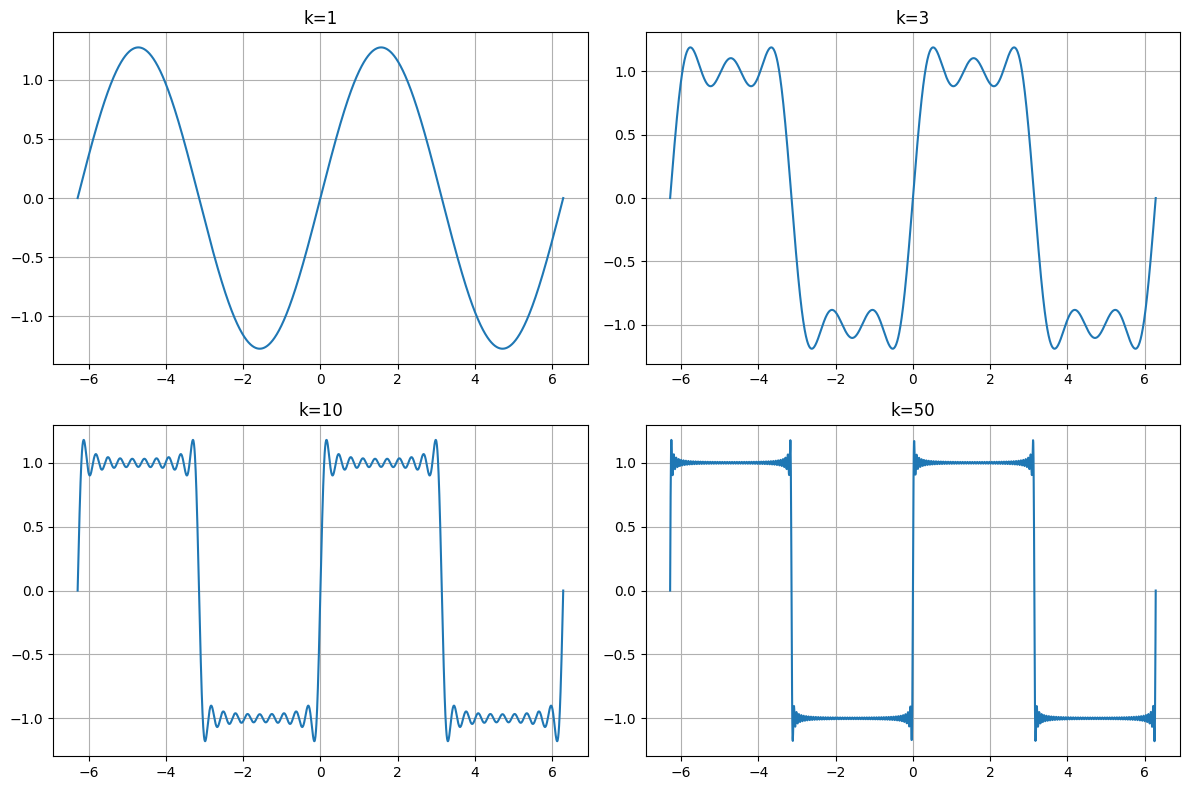

In [276]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 푸리에 급수로 구형파 근사 함수
# -----------------------------
def square_wave_fourier(x, n_terms):
    y = np.zeros_like(x)
    for k in range(1, 2 * n_terms, 2):   # 1, 3, 5, 7, ...
        y += np.sin(k * x) / k
    #return y
    return (4 / np.pi) * y

# -----------------------------
# x축 생성
# -----------------------------
x = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
# 항의 개수별 구형파 근사
y1 = square_wave_fourier(x, 1)
y3 = square_wave_fourier(x, 3)
y10 = square_wave_fourier(x, 10)
y50 = square_wave_fourier(x, 50)

# -----------------------------
# 그래프 출력
# -----------------------------
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(x, y1)
plt.title("k=1")
plt.grid(True)
plt.subplot(2, 2, 2)
plt.plot(x, y3)
plt.title("k=3")
plt.grid(True)
plt.subplot(2, 2, 3)
plt.plot(x, y10)
plt.title("k=10")
plt.grid(True)
plt.subplot(2, 2, 4)
plt.plot(x, y50)
plt.title("k=50")
plt.grid(True)
plt.tight_layout()

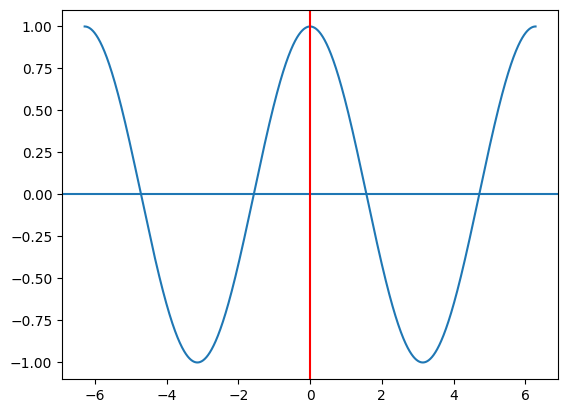

In [277]:
y = np.cos(x)

plt.plot(x, y)
plt.axhline(0, -4)
plt.axvline(0, -1, 1, color='red')

In [278]:
def fc_square(x, n_terms):
    y = np.zeros_like(x)
    for k in range(1, 2*n_terms, 2):
        i = (-1)**((k-1)//2)
        y = y + i * np.cos(k*x)/k
    return 2 + (8/np.pi)*y

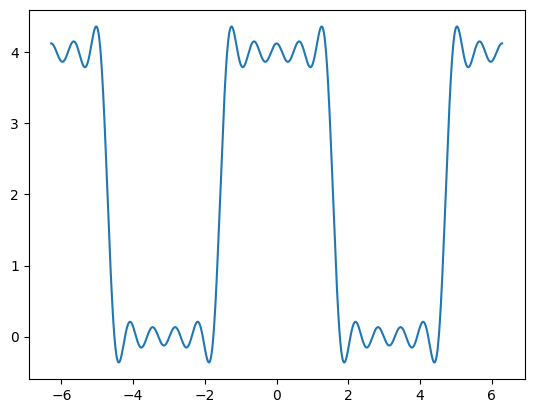

In [279]:
plt.plot(x, fc_square(x, 5))

low-pass filter

# 회귀 계수 구하기

최소제곱법 (OLS), 최대우도법(MLE), 경사하강법

최대우도법으로 회귀 계수 구하기

$$\epsilon \sim N(0, \sigma^2)$$

회귀식

$
y = ax + b + \epsilon
$


### Log -likelihood function 로그 우도 함수

$$
P(x|\theta) = P(x_1|\theta) \times P(x_2|\theta)
$$
<br>
$$
L(\theta | x) \xrightarrow{\text{향후}} L(\theta ; x)
$$

In [280]:
x = np.array([1, 2, 3])
y = np.array([5, 7, 9])

In [281]:
coeff = np.polyfit(x, y ,1)

In [282]:
coeff

array([2., 3.])

In [283]:
f1 = np.poly1d(coeff)

In [284]:
x_data = np.arange(1, 10, 1)

In [285]:
f1(x_data)

array([ 5.,  7.,  9., 11., 13., 15., 17., 19., 21.])

In [286]:
data = {'x' : [13, 19, 16, 14, 15, 18],
        'y' : [40, 83, 62, 57, 58, 63]}

In [287]:
data = pd.DataFrame(data)

In [288]:
data

,x,y
0,13,40
1,19,83
2,16,62
3,14,57
4,15,58
5,18,63


In [289]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

<Axes: xlabel='x', ylabel='y'>

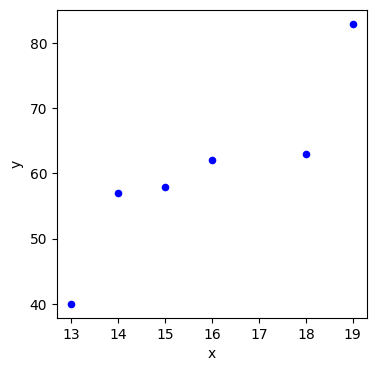

In [290]:
data.plot(kind='scatter', x='x', y='y', figsize=(4, 4), color='b')

In [291]:
linear_regression = linear_model.LinearRegression() # 선형회귀

In [292]:
data['x'].values[:, np.newaxis]

array([[13],
       [19],
       [16],
       [14],
       [15],
       [18]])

In [293]:
linear_regression.fit(data['x'].values[:, np.newaxis], y=data['y'])

LinearRegression()

In [294]:
print('b value:', linear_regression.intercept_)

b value: -24.173913043478294


In [295]:
print('a value:', linear_regression.coef_)

a value: [5.34782609]


In [296]:
prediction = linear_regression.predict(data['x'].values[:, np.newaxis])

Text(17.7, 61.5, '$(x_2, y_2)$')

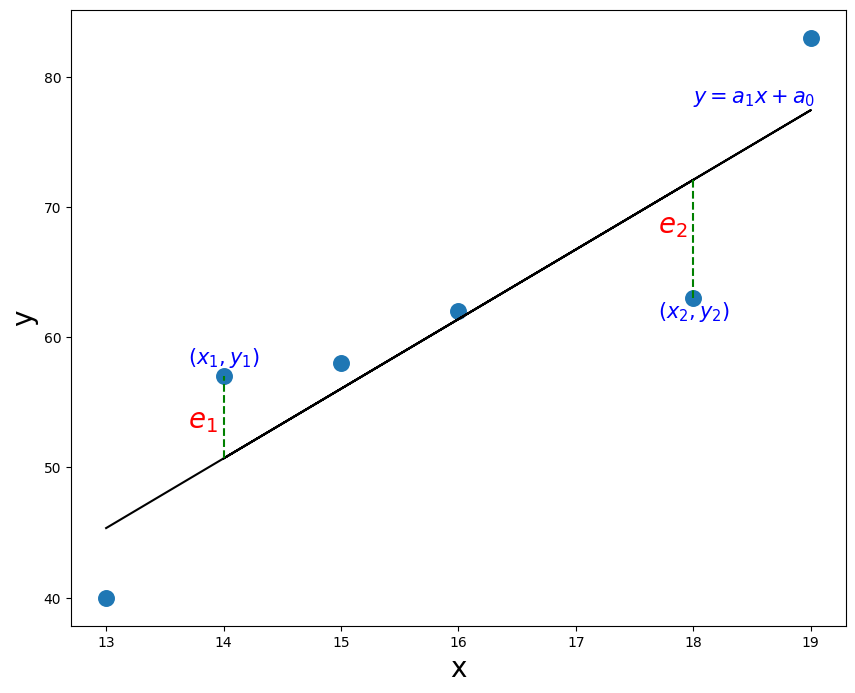

In [298]:
plt.figure(figsize=(10, 8))
plt.scatter(data.x, data.y, s=125)
plt.plot(data.x, prediction, color='black')
plt.vlines(14, 50.7, 57, colors='green', linestyle='--')
plt.vlines(18, 63, 72.09, colors='green', linestyle='--')
plt.text(13.7, 53, r'$e_1$', size=20, color='red')
plt.text(17.7, 68, r'$e_2$', size=20, color='red')
plt.text(18, 78, r'$y=a_1 x + a_0$',size=15, color='blue')
plt.ylabel('y', size=20)
plt.xlabel('x', size=20)
plt.text(13.7, 58, r'$(x_1, y_1)$', size=15, color='blue')
plt.text(17.7, 61.5, r'$(x_2, y_2)$', size=15, color='blue')

In [299]:
residuals = data['y'] - prediction
for i in range(len(residuals)):
    print(data['y'][i], ' - ', np.round(prediction[i], 2), ' = ', np.round(residuals[i], 2))

40  -  45.35  =  -5.35
83  -  77.43  =  5.57
62  -  61.39  =  0.61
57  -  50.7  =  6.3
58  -  56.04  =  1.96
63  -  72.09  =  -9.09


$$e_1 = y_1 - (a_1 x_1 + a_0) \\ $$


$$e_2 = y_2 - (a_1 x_2 + a_0) \\ $$


$$\therefore \ e_i = y_i - (a_1 x_i + a_0) \\ $$

$$ S =\ min\ \sum_{i=1}^{n}\ e_i^2\ =\ min\ \sum_{i=1}^{n}\ (y_i - a_1 x_i - a_0 ) ^ 2 \\ $$

$ {\partial\ S \over \partial\ a_1}\ =\ 0 \ $ 이고, $ {\partial\ S \over \partial\ a_0}\ =\ 0 \ $ 인, $a_1, \ a_0 \ $ 를 찾아야 한다.

In [301]:
x = data.x.values
y = data.y.values

In [303]:
sum_xy = np.sum(x*y)
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_x_square = np.sum(x*x)
n = data.x.count()

In [304]:
n

np.int64(6)

In [305]:
a_1 = (n*sum_xy - sum_x * sum_y) / (n * sum_x_square - sum_x*sum_x)

In [307]:
a_1

np.float64(5.3478260869565215)

In [308]:
a_0 = np.mean(y) - np.mean(x) * a_1

In [310]:
a_0

np.float64(-24.173913043478265)

In [311]:
RSS = (residuals**2).sum()
TSS = ((data['y']-data['y'].mean())**2).sum()

In [312]:
RSS

np.float64(186.08695652173932)

In [313]:
TSS

np.float64(953.5)

In [314]:
R_squared = 1- (RSS/TSS)

In [315]:
R_squared

np.float64(0.8048380109892613)

In [316]:
linear_regression.score(X = pd.DataFrame(data['x']), y = data['y'])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


0.8048380109892613

MAE (Mean Absolute Error) : 자료의 특성을 직관적으로 파악하게 한다.
$$ MAE = {1 \over n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
MSE (Mean Squared Error) : 실제값과 예측값의 차이를 제곱해 평균한 것
$$ MSE = {1 \over n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
RMSE (Root Mean Squared Error)
$$RMSE = \sqrt{MSE} = \sqrt {{1 \over n} \sum_{i=1}^n (y_i - \hat{y}_i)^2} = {1 \over \sqrt{n}} \sqrt{\sum_{i=1}^n (y_i - \hat{y}_i)^2}  $$

In [317]:
RSS / 6

np.float64(31.01449275362322)

# 경사하강법

$${1 \over N} \sum_{i=1}^N (y_i - (w_0 + w_1 \times x_i))^2 $$
<br>
<br>
## $$ {{\partial MSE} \over {\partial w_1} } = {2 \over N} \sum_{i=1}^N (-x_i) (y_i - (w_0 + w_1 \times x_i))  $$
## $$ {{\partial MSE} \over {\partial w_0} } = {2 \over N} \sum_{i=1}^N (-1) (y_i - (w_0 + w_1 \times x_i))  $$

$$ 새로운 \ w_1 = 이전 \ w_1 - {{\partial MSE} \over {\partial w_1} }$$

$$ 새로운 \ w_0 = 이전 \ w_0 - {{\partial MSE} \over {\partial w_0} }$$

1. W0, W1을 임의의 값으로 설정 --> MSE 산출
2. 새로운 w1 = 0, w1을 계산하고, 다시 MSE 산출

$$
w_1 = w_1 + \eta {2 \over N} \sum_{i=1}^N (x_i) (실제값 - 예측값)
$$
$$
w_0 = w_0 + \eta {2 \over N} \sum_{i=1}^N (실제값 - 예측값)
$$

3. MSE값이 감소하기 시작하면 1번, 2번을 계속 반복, 감소를 멈추면 프로그램 끝